# Brain Tumor Detection with YOLO

## Install Required Libraries

In [ ]:
!pip install -q ultralytics opencv-python-headless matplotlib pandas seaborn plotly pyyaml streamlit pyngrok streamlit


## Imports & Reproducibility

In [ ]:
import os
import random
import shutil
from pathlib import Path

import cv2
import yaml
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {'GPU' if device == '0' else 'CPU'}")
if device == "0":
    print("GPU Name:", torch.cuda.get_device_name(0))


Using device: GPU
GPU Name: NVIDIA GeForce RTX 3050


## Dataset Setup

In [ ]:
DATASET_ROOT = Path("dataset")


# Paths to data directories
train_path = DATASET_ROOT / "Train"
val_path = DATASET_ROOT / "Val"
test_path = DATASET_ROOT / "Test"

print("train_path:", train_path)
print("val_path:", val_path)
print("test_path:", test_path)


train_path: dataset\Train
val_path: dataset\Val
test_path: dataset\Test


## Classes

In [ ]:
classes = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
class_to_id = {c: i for i, c in enumerate(classes)}
print(class_to_id)


{'Glioma': 0, 'Meningioma': 1, 'No Tumor': 2, 'Pituitary': 3}


## Small-Sample Loading for Visualization

In [ ]:
def load_sample(data_path, n_per_class=6):
    images, labels_per_image, img_paths = [], [], []
    for cls in classes:
        img_dir = Path(data_path) / cls / "images"
        label_dir = Path(data_path) / cls / "labels"
        candidates = [p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
        sample = random.sample(candidates, min(n_per_class, len(candidates)))
        for img_path in sample:
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            label_path = label_dir / (img_path.stem + ".txt")
            boxes = []
            if label_path.exists():
                for line in label_path.read_text().splitlines():
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split()
                    boxes.append((float(parts[0]), *map(float, parts[1:5])))  # ALL lines, not just the first
            images.append(img)
            labels_per_image.append(boxes)
            img_paths.append(img_path)
    return images, labels_per_image, img_paths

train_sample_images, train_sample_labels, train_sample_paths = load_sample(train_path, n_per_class=6)
print(f"Loaded {len(train_sample_images)} sample images for visualization "
      f"(avg {np.mean([len(b) for b in train_sample_labels]):.2f} boxes/image)")


Loaded 24 sample images for visualization (avg 1.08 boxes/image)


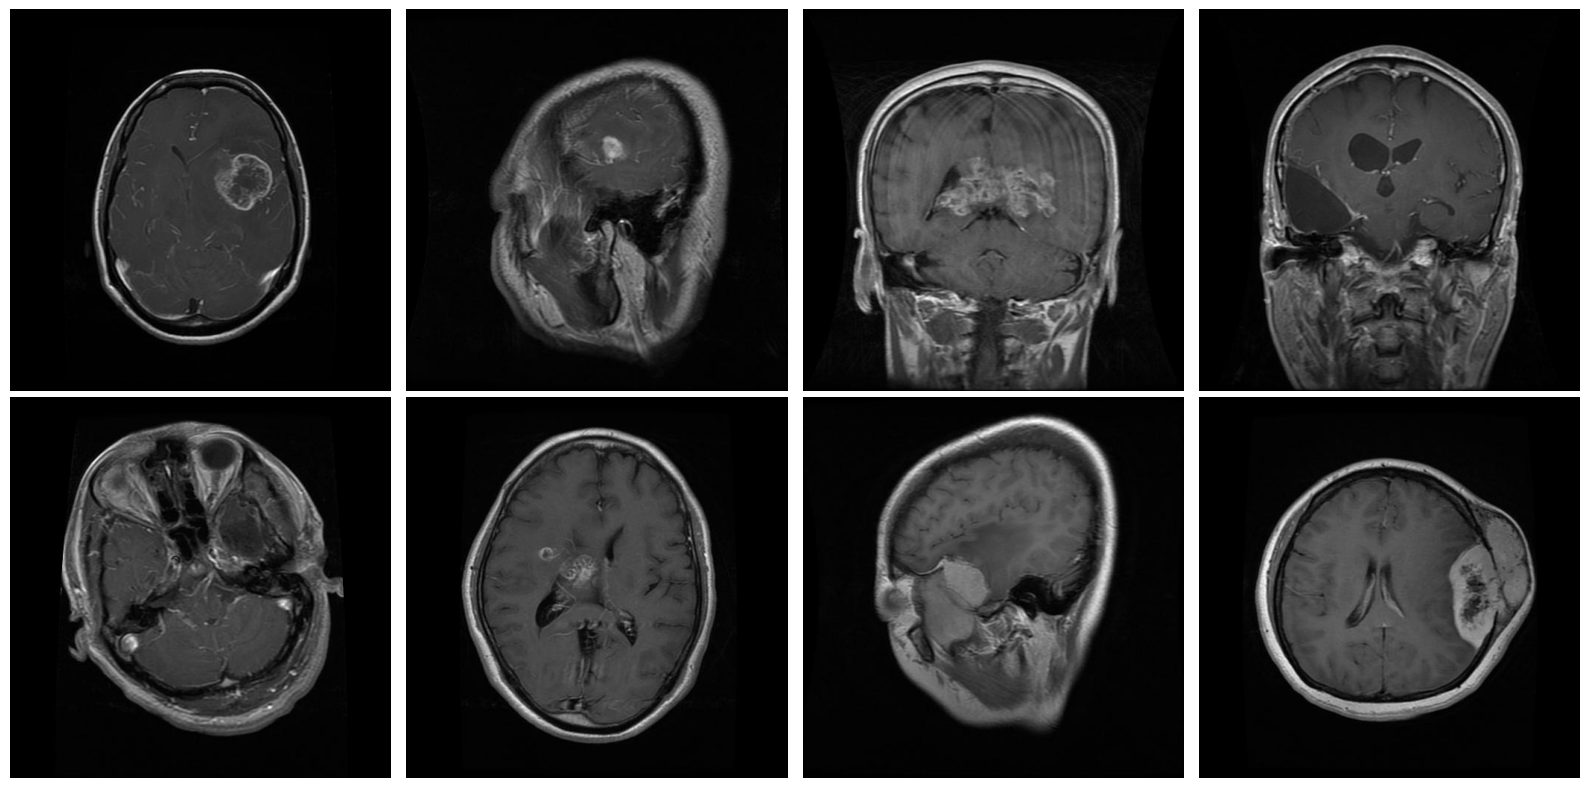

In [ ]:
# Visualize a few raw images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, img in zip(axes.flat, train_sample_images[:8]):
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()


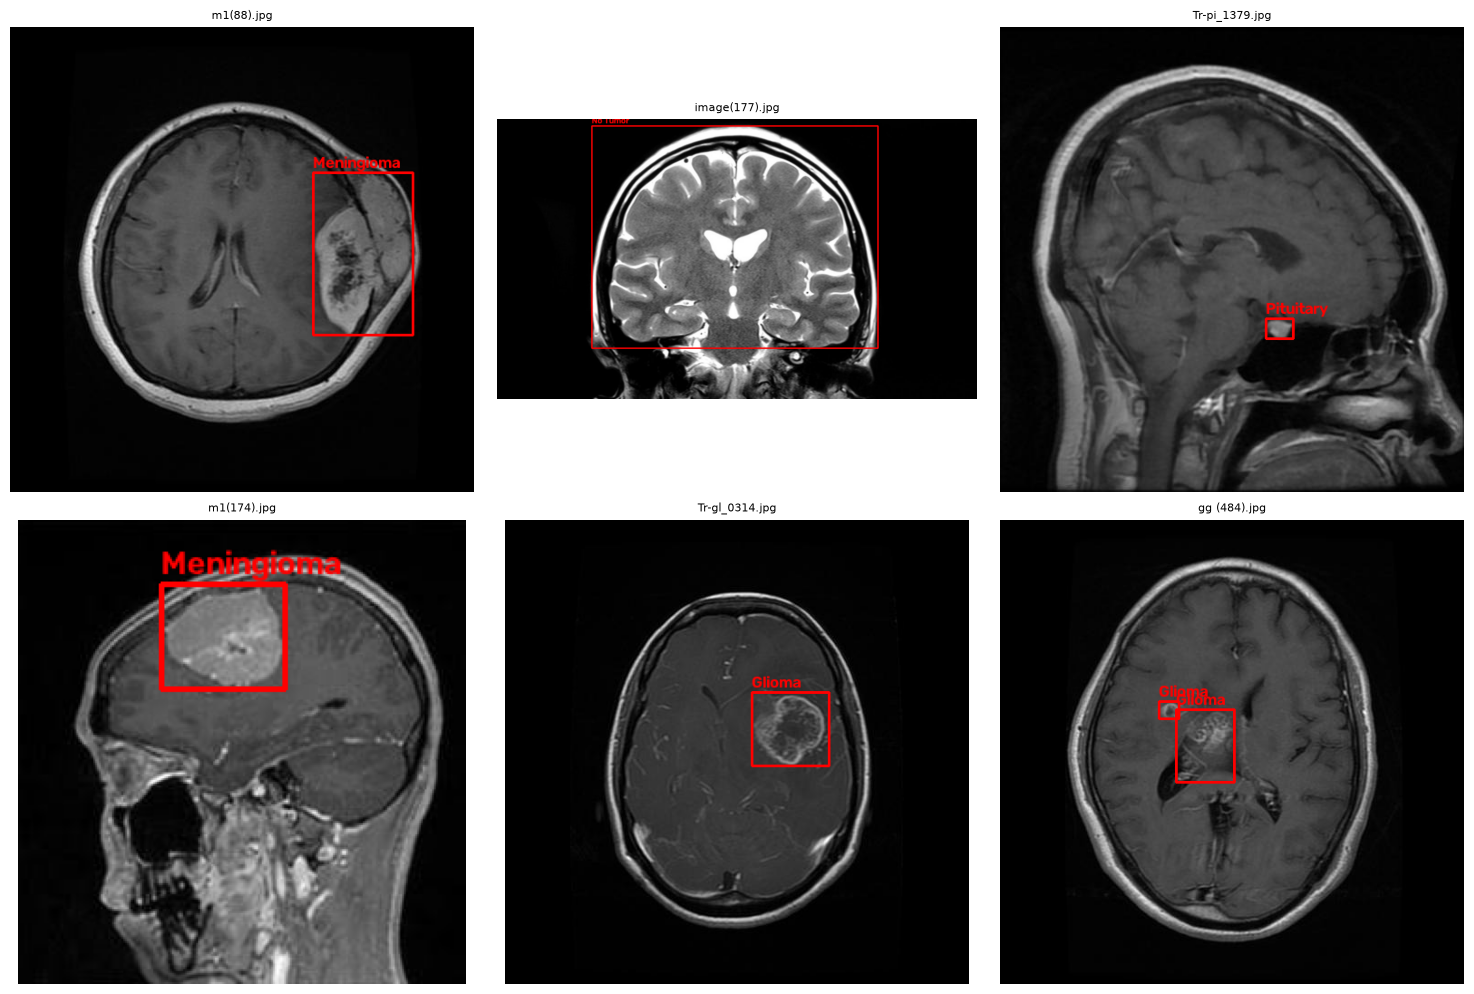

In [ ]:
def yolo_to_xyxy(box, img_w, img_h):
    cls, xc, yc, w, h = box
    xc, yc, w, h = xc * img_w, yc * img_h, w * img_w, h * img_h
    x1, y1 = xc - w / 2, yc - h / 2
    x2, y2 = xc + w / 2, yc + h / 2
    return int(cls), int(x1), int(y1), int(x2), int(y2)

def plot_samples_with_boxes(images, labels_per_image, paths, class_names, n=6):
    idxs = random.sample(range(len(images)), min(n, len(images)))
    cols = 3
    rows = (len(idxs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, i in zip(axes, idxs):
        img = images[i].copy()
        h, w = img.shape[:2]
        for box in labels_per_image[i]:  # draws ALL boxes now, not just the first
            cls, x1, y1, x2, y2 = yolo_to_xyxy(box, w, h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            label = class_names[cls] if cls < len(class_names) else str(cls)
            cv2.putText(img, label, (x1, max(y1 - 5, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
        ax.imshow(img)
        ax.set_title(paths[i].name, fontsize=8)
        ax.axis("off")

    for ax in axes[len(idxs):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_samples_with_boxes(train_sample_images, train_sample_labels, train_sample_paths, classes, n=6)


## Class Distribution

In [ ]:
def count_per_class(split_path):
    return [len(list((Path(split_path) / cls / "images").glob("*"))) for cls in classes]

eda_df = pd.DataFrame({
    "Class": classes,
    "Train": count_per_class(train_path),
    "Validation": count_per_class(val_path),
    "Test": count_per_class(test_path),
})
print(eda_df)

fig = go.Figure(data=[
    go.Bar(name="Train", x=eda_df["Class"], y=eda_df["Train"]),
    go.Bar(name="Validation", x=eda_df["Class"], y=eda_df["Validation"]),
    go.Bar(name="Test", x=eda_df["Class"], y=eda_df["Test"]),
])
fig.update_layout(barmode="group", title="Class Distribution Across Splits")
fig.show()


        Class  Train  Validation  Test
0      Glioma    900         112   112
1  Meningioma   1187         148   148
2    No Tumor    649          80    80
3   Pituitary   1249         155   155


## Create YOLO Config (`data.yaml`)

In [ ]:
dataset_yaml = {
    "path": str(DATASET_ROOT.resolve()),
    "train": "Train",
    "val": "Val",
    "test": "Test",
    "nc": len(classes),
    "names": classes,
}

with open("dataset.yaml", "w") as f:
    yaml.dump(dataset_yaml, f, sort_keys=False)

print(dataset_yaml)


{'path': 'D:\\Programs\\Work_in_progress\\brain_tumor_detection\\dataset', 'train': 'Train', 'val': 'Val', 'test': 'Test', 'nc': 4, 'names': ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']}


## YOLOv8 Training

In [ ]:
MODEL_SIZE = "yolov8s.pt"
EPOCHS = 30
IMG_SIZE = 640
BATCH = 8

# Dynamic path: relative to current working directory
WEIGHTS_DIR = Path.cwd() / "runs" / "detect"

yolo_model = YOLO(MODEL_SIZE)

train_results = yolo_model.train(
    data="dataset.yaml",
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    workers=0,
    batch=BATCH,
    device=device,
    seed=SEED,
    patience=15,
    hsv_h=0.0,   
    hsv_s=0.0,   
    hsv_v=0.2,   
    project=str(WEIGHTS_DIR),
    name="brain_tumor_train",
    exist_ok=True,
)

New https://pypi.org/project/ultralytics/8.4.136 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.131  Python-3.13.7 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yo

## Load the Best Checkpoint

In [ ]:
best_weights_path = Path(train_results.save_dir) / "weights" / "best.pt"
print("Best weights:", best_weights_path)

best_model = YOLO(str(best_weights_path))

# Keep a copy of the weights alongside the notebook for easy reuse/export
shutil.copy(best_weights_path, "yolov8_brain_tumor_best.pt")


Best weights: D:\Programs\Work_in_progress\brain_tumor_detection\runs\detect\brain_tumor_train\weights\best.pt


'yolov8_brain_tumor_best.pt'

## Validation

In [ ]:
def run_and_report(split_name):
    metrics = best_model.val(
            data="dataset.yaml",
            split=split_name,
            imgsz=IMG_SIZE,
            batch=BATCH,
            device=device,
            project=str((WEIGHTS_DIR / "detect").resolve()),
            plots=True
        )
    print(f"--- {split_name.upper()} ---")
    print(f"mAP50:    {metrics.box.map50:.4f}")
    print(f"mAP50-95: {metrics.box.map:.4f}")
    print(f"Precision:{metrics.box.mp:.4f}")
    print(f"Recall:   {metrics.box.mr:.4f}")
    print("Per-class mAP50-95:")
    for cls_name, ap in zip(classes, metrics.box.maps):
        print(f"  {cls_name}: {ap:.4f}")
    print()
    return metrics

val_metrics = run_and_report("val")
test_metrics = run_and_report("test")


Ultralytics 8.4.131  Python-3.13.7 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050, 6144MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 138.246.2 MB/s, size: 26.2 KB)
val: Scanning D:\Programs\Work_in_progress\brain_tumor_detection\dataset\Val\Glioma\labels.cache... 495 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 495/495 173.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 7.3it/s 8.5s0.1s
                   all        495        529      0.951      0.924      0.963      0.768
                Glioma        112        132      0.932      0.833      0.932      0.721
            Meningioma        148        152      0.978      0.961       0.97      0.814
              No Tumor         80         80      0.964      0.988      0.994      0.806
             Pituitary        155        165      0.929      0.915      0.955

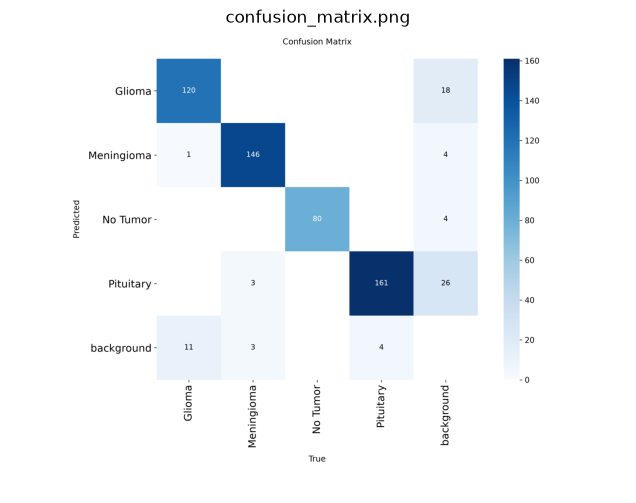

In [ ]:
# Display the confusion matrix and PR/F1 curves Ultralytics saves automatically
run_dir = Path(val_metrics.save_dir)
for fname in ["confusion_matrix.png", "PR_curve.png", "F1_curve.png"]:
    fpath = run_dir / fname
    if fpath.exists():
        img = plt.imread(fpath)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(fname)
        plt.show()


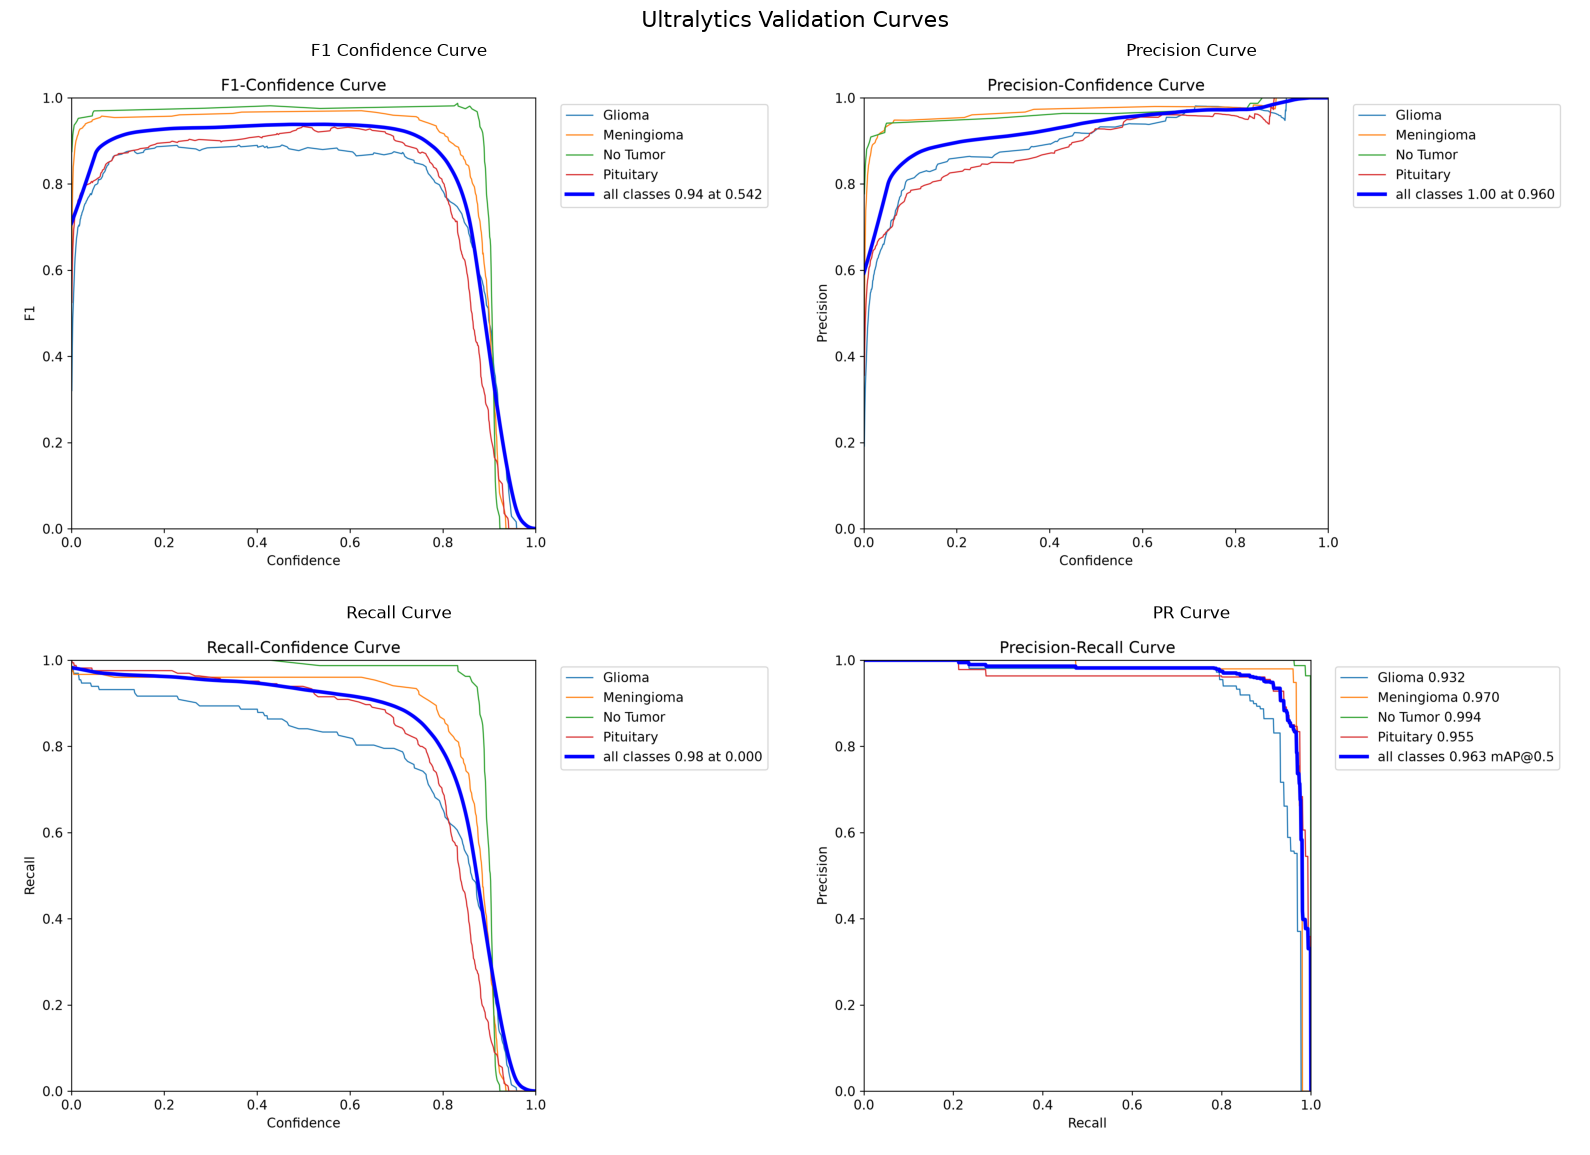

In [ ]:
# Visualize the main validation curves in one place
curve_files = {
    "F1 Confidence Curve": "BoxF1_curve.png",
    "Precision Curve": "BoxP_curve.png",
    "Recall Curve": "BoxR_curve.png",
    "PR Curve": "BoxPR_curve.png",
}

run_dir = Path(val_metrics.save_dir)
available_curves = [
    (title, run_dir / filename)
    for title, filename in curve_files.items()
    if (run_dir / filename).exists()
]

if not available_curves:
    print(f"No curve images found in {run_dir}")
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()
    for ax, (title, fpath) in zip(axes, available_curves):
        img = plt.imread(fpath)
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[len(available_curves):]:
        ax.axis("off")

    fig.suptitle("Ultralytics Validation Curves", fontsize=16)
    plt.tight_layout()
    plt.show()


## Inference Visualization

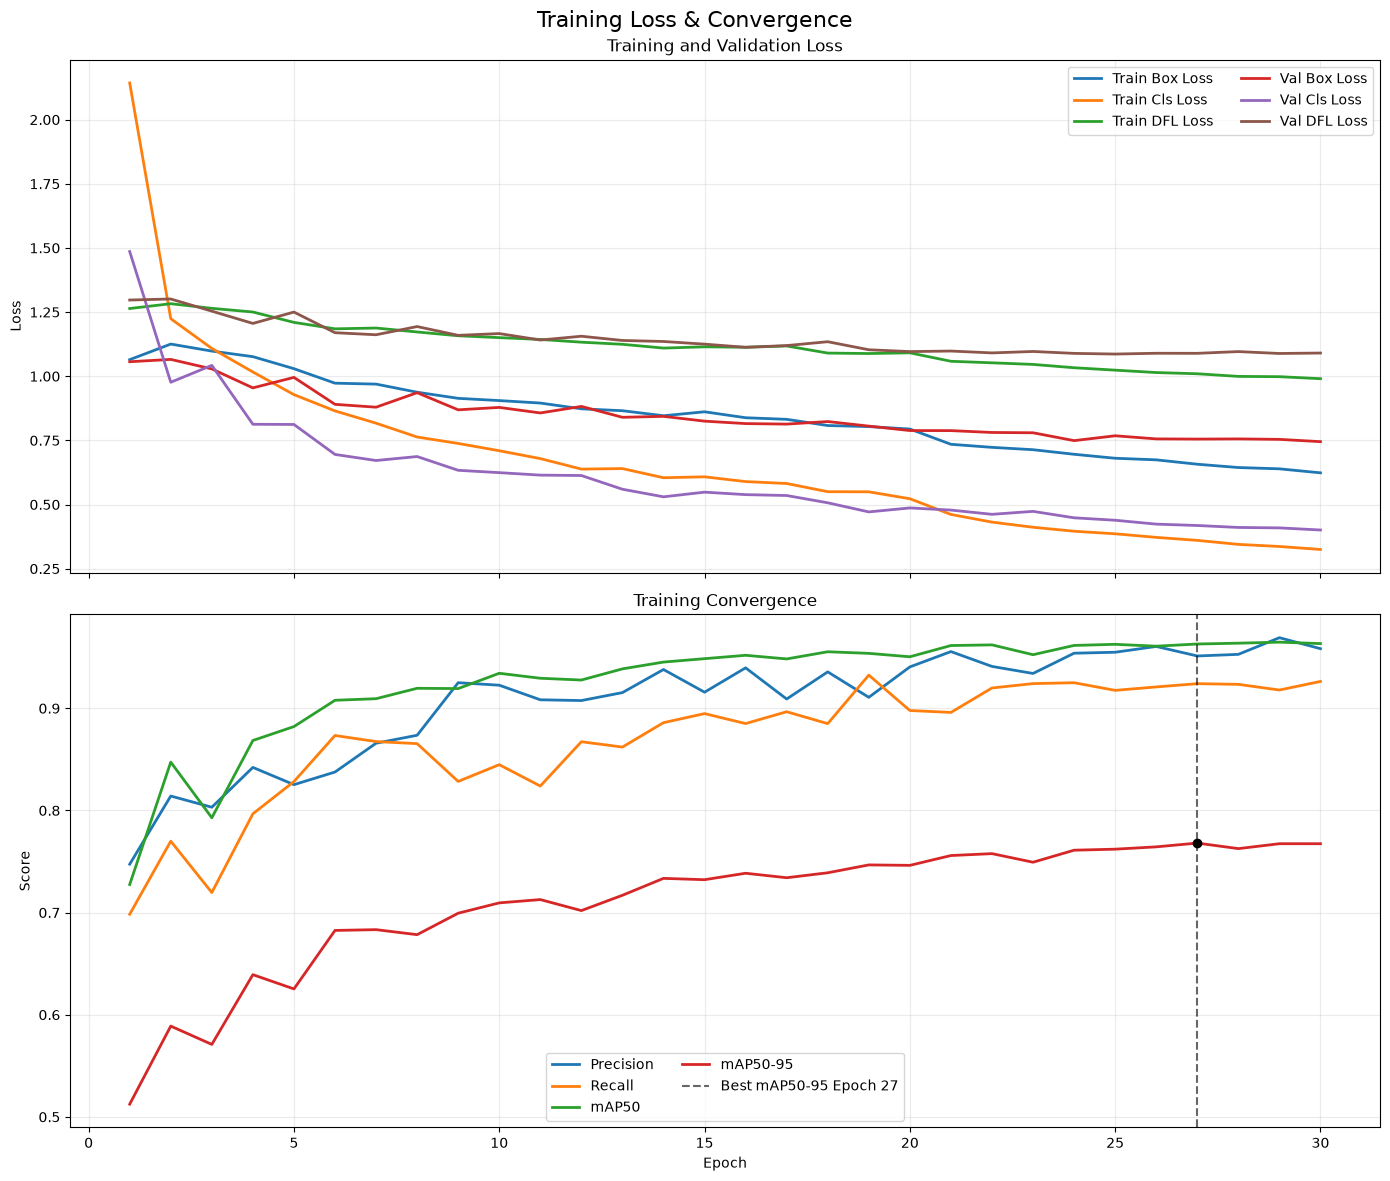

In [ ]:
# Visualize training loss and convergence from the saved training log
results_path = Path(train_results.save_dir) / "results.csv"
if not results_path.exists():
    print(f"results.csv not found at {results_path}")
else:
    results_df = pd.read_csv(results_path)
    results_df.columns = [c.strip() for c in results_df.columns]
    results_df["epoch"] = results_df["epoch"].astype(int)

    loss_cols = {
        "Train Box Loss": "train/box_loss",
        "Train Cls Loss": "train/cls_loss",
        "Train DFL Loss": "train/dfl_loss",
        "Val Box Loss": "val/box_loss",
        "Val Cls Loss": "val/cls_loss",
        "Val DFL Loss": "val/dfl_loss",
    }
    metric_cols = {
        "Precision": "metrics/precision(B)",
        "Recall": "metrics/recall(B)",
        "mAP50": "metrics/mAP50(B)",
        "mAP50-95": "metrics/mAP50-95(B)",
    }

    best_idx = results_df["metrics/mAP50-95(B)"].idxmax()
    best_epoch = int(results_df.loc[best_idx, "epoch"])
    best_map = float(results_df.loc[best_idx, "metrics/mAP50-95(B)"])

    fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

    ax = axes[0]
    for label, col in loss_cols.items():
        ax.plot(results_df["epoch"], results_df[col], linewidth=2, label=label)
    ax.set_title("Training and Validation Loss")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2)

    ax = axes[1]
    for label, col in metric_cols.items():
        ax.plot(results_df["epoch"], results_df[col], linewidth=2, label=label)
    ax.axvline(best_epoch, color="black", linestyle="--", alpha=0.6, label=f"Best mAP50-95 Epoch {best_epoch}")
    ax.scatter([best_epoch], [best_map], color="black", zorder=5)
    ax.set_title("Training Convergence")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2)

    fig.suptitle("Training Loss & Convergence", fontsize=16)
    plt.tight_layout()
    plt.show()


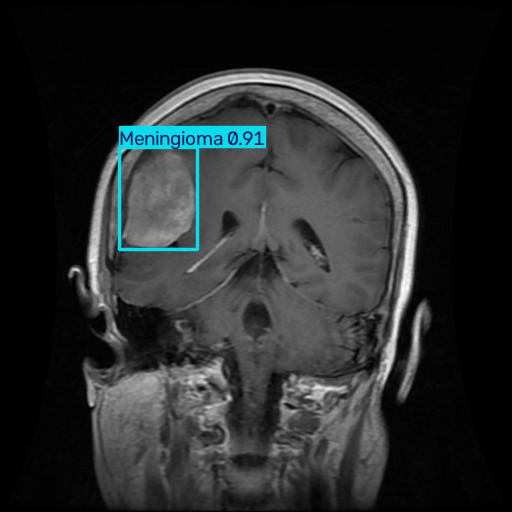

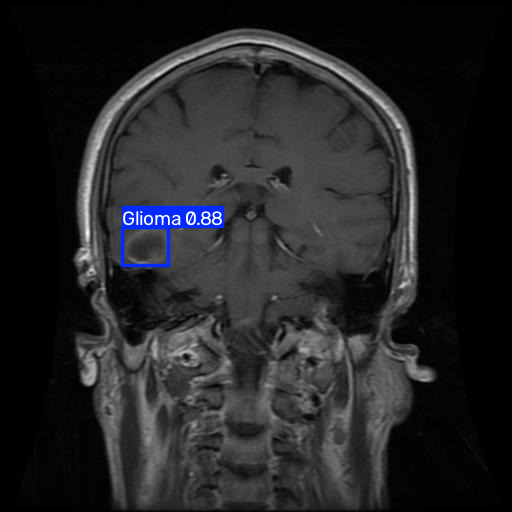

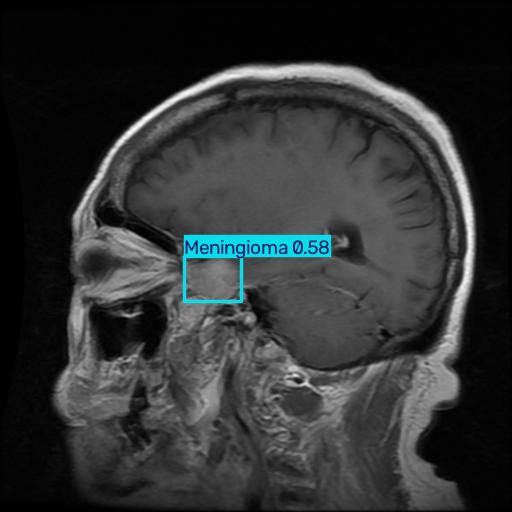

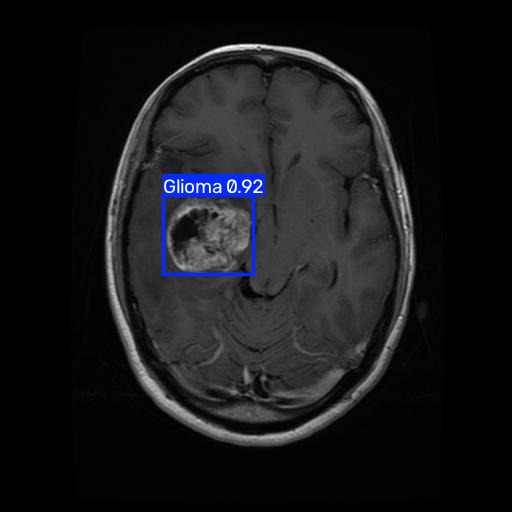

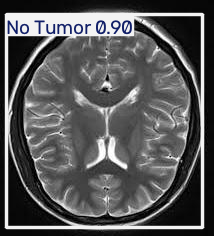

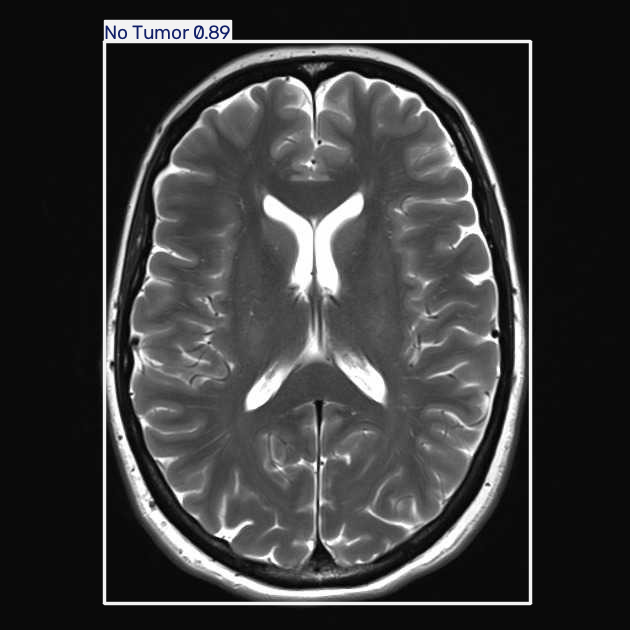

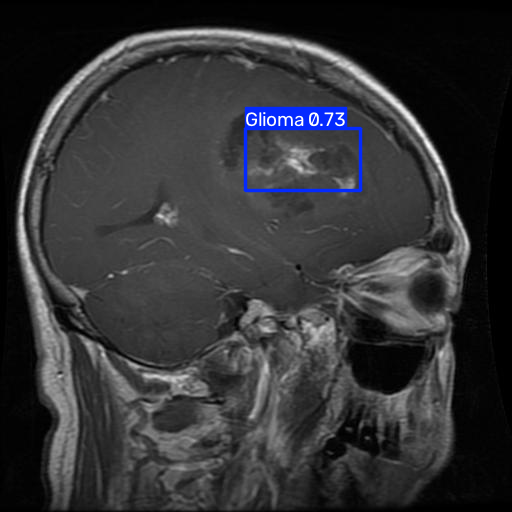

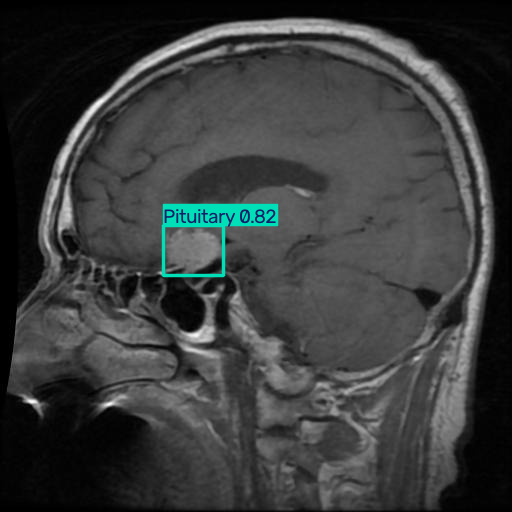

In [ ]:
from IPython.display import Image as IPImage, display

def display_predictions(split_path, sample_count=8, confidence=0.25):
    all_images = []
    for cls in classes:
        all_images.extend((Path(split_path) / cls / "images").glob("*"))
    sample = random.sample(all_images, min(sample_count, len(all_images)))

    results = best_model.predict(source=[str(p) for p in sample], imgsz=IMG_SIZE, conf=confidence, verbose=False)
    for r in results:
        annotated = r.plot()  # BGR array with boxes drawn
        success, encoded = cv2.imencode(".png", annotated)
        if success:
            display(IPImage(data=encoded.tobytes(), format="png"))

display_predictions(test_path, sample_count=8)
